In [1]:
# import packages

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import keras
from keras import backend as K
from keras.layers import Input, Dense, Lambda
from keras.models import Model
from keras.callbacks import History
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib
from sklearn.decomposition import PCA
from minisom import MiniSom

2025-07-03 10:02:34.255769: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-03 10:02:34.255855: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-03 10:02:34.342682: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 10:02:34.635374: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Import Data (scaled and sequential)

In [2]:
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt

scaled_input_ohc_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_train_robustscaler.csv', delimiter=',')
scaled_input_ohc_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_test_robustscaler.csv', delimiter=',')

scaled_input_sst_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_train_robustscaler.csv', delimiter=',')
scaled_input_sst_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_test_robustscaler.csv', delimiter=',')

scaled_input_olr_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.csv', delimiter=',')
scaled_input_olr_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.csv', delimiter=',')

In [3]:
# load netcdf files with time component 
sequential_input_ohc_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_train_robustscaler.nc')
sequential_input_ohc_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_test_robustscaler.nc')

sequential_input_olr_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.nc')
sequential_input_olr_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.nc')

sequential_input_sst_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_train_robustscaler.nc')
sequential_input_sst_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/sst_test_robustscaler.nc')

In [4]:
scaled_input_olr_train[:10]

array([[-0.13592516, -0.15422471, -0.10487127, ..., -1.00696635,
        -1.57224238, -1.56264472],
       [ 0.50404596,  0.48380584,  0.4865295 , ..., -1.05872321,
        -1.45092595, -1.42210627],
       [-1.40209067, -0.98124057, -0.6988914 , ...,  0.28162995,
         0.39260817,  0.49944344],
       ...,
       [-2.23494005, -2.02849984, -2.0067246 , ..., -0.69058853,
        -0.4744837 , -0.09201477],
       [ 0.03300727, -0.19273035, -0.47158346, ...,  0.36852723,
         0.29735371,  0.27511233],
       [ 0.46322525,  0.50955927,  0.54607534, ...,  0.74676704,
         1.0181216 ,  0.8303768 ]])

In [5]:
sequential_input_olr_train[:10]

<xarray.DataArray (time: 10, newdim: 2662)> Size: 106kB
array([[-0.13592516, -0.15422471, -0.10487127, ..., -1.0069664 ,
        -1.5722424 , -1.5626447 ],
       [ 0.50404596,  0.48380584,  0.4865295 , ..., -1.0587232 ,
        -1.450926  , -1.4221063 ],
       [-1.4020907 , -0.9812406 , -0.6988914 , ...,  0.28162995,
         0.39260817,  0.49944344],
       ...,
       [-2.23494   , -2.0284998 , -2.0067246 , ..., -0.69058853,
        -0.4744837 , -0.09201477],
       [ 0.03300727, -0.19273035, -0.47158346, ...,  0.36852723,
         0.2973537 ,  0.27511233],
       [ 0.46322525,  0.5095593 ,  0.54607534, ...,  0.74676704,
         1.0181216 ,  0.8303768 ]], dtype=float32)
Coordinates:
  * time     (time) object 80B 0282-10-01 00:00:00 ... 0100-10-01 00:00:00
    month    (time) int64 80B 10 8 1 7 2 5 1 2 10 10
    lat      (newdim) float64 21kB -9.895 -9.895 -9.895 ... 9.895 9.895 9.895
    lon      (newdim) float64 21kB 130.0 131.2 132.5 133.8 ... 277.5 278.8 280.0
Dimensions without coordinates: newdim

In [6]:
# sanity checks
print(scaled_input_sst_train.shape,
     scaled_input_sst_test.shape,
     scaled_input_ohc_train.shape,
     scaled_input_ohc_test.shape,
     scaled_input_olr_train.shape,
     scaled_input_olr_test.shape)

(4800, 2968) (1200, 2968) (4800, 2960) (1200, 2960) (4800, 2662) (1200, 2662)


## Build Variational Autoencoder

In [7]:
# set random seed
keras.utils.set_random_seed(1)

In [8]:
# check input shape for sst
input_shape_sst = scaled_input_sst_train.shape[1]
print(input_shape_sst)

# check input shape for ssh
input_shape_ohc = scaled_input_ohc_train.shape[1]
print(input_shape_ohc)

# check input shape for zonal stress
input_shape_olr = scaled_input_olr_train.shape[1]
print(input_shape_olr)

2968
2960
2662


In [9]:
# define latent space (going to be 2 here)
latent_dim = 20

In [10]:
# sst input
input_sst = Input(shape=(np.int64(input_shape_sst),), name='input_sst')
print(input_sst.shape)

# add 2 dense layers
encoded_sst_layer1 = Dense(400, activation='tanh')(input_sst)
encoded_sst_layer2 = Dense(250, activation='tanh')(encoded_sst_layer1)
encoded_sst_layer3 = Dense(180, activation='tanh')(encoded_sst_layer2)
encoded_sst_layer4 = Dense(100, activation='tanh')(encoded_sst_layer3)
encoded_sst_layer5 = Dense(30, activation='tanh')(encoded_sst_layer4)

# ohc input
input_ohc = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc')
print(input_ohc.shape)

# add 2 dense layers (again)
encoded_ohc_layer1 = Dense(400, activation='tanh')(input_ohc)
encoded_ohc_layer2 = Dense(250, activation='tanh')(encoded_ohc_layer1)
encoded_ohc_layer3 = Dense(180, activation='tanh')(encoded_ohc_layer2)
encoded_ohc_layer4 = Dense(100, activation='tanh')(encoded_ohc_layer3)
encoded_ohc_layer5 = Dense(30, activation='tanh')(encoded_ohc_layer4)

# zonal stress input 
# ssh input
input_olr = Input(shape=(np.int64(input_shape_olr),),
                          name='input_olr')
print(input_olr.shape)

# add 2 dense layers (again)
encoded_olr_layer1 = Dense(400, activation='tanh')(input_olr)
encoded_olr_layer2 = Dense(250, activation='tanh')(encoded_olr_layer1)
encoded_olr_layer3 = Dense(180, activation='tanh')(encoded_olr_layer2)
encoded_olr_layer4 = Dense(100, activation='tanh')(encoded_olr_layer3)
encoded_olr_layer5 = Dense(30, activation='tanh')(encoded_olr_layer4)

(None, 2968)


2025-07-03 10:04:35.438911: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


(None, 2960)
(None, 2662)


In [11]:
# concatenate inputs before passing through latent space
encoder_output_concat = keras.layers.Concatenate()([encoded_sst_layer5,
                        encoded_ohc_layer5,
                        encoded_olr_layer5]
                      )

In [12]:
# create latent space with z_mean and z_log_var
# this will create dense layers with 2 nodes because of latent_dim 

z_mean = Dense(latent_dim, name='z_mean')(encoder_output_concat)
z_log_var = Dense(latent_dim, name='z_log_var')(encoder_output_concat)

In [13]:
# reparameterization trick 
# "we now treat random sampling as a noise term
# the standard normal is a gaussian distribution with mean mu = 0 and sigma = 1
# https://medium.com/@weidagang/demystifying-neural-networks-variational-autoencoders-6a44e75d0271

def sampling(args):
    z_mean, z_log_var = args
    
    epsilon = keras.backend.random_normal(shape=keras.backend.shape(z_mean), mean=0., stddev=1.)
    return z_mean + keras.backend.exp(z_log_var / 2) * epsilon

In [14]:
z = Lambda(sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean, z_log_var])

In [15]:
# build decoder for each variable from the latent space
# sst
decoded1_sst = Dense(30, activation='tanh')(z)
decoded2_sst = Dense(100, activation='tanh')(decoded1_sst)
decoded3_sst = Dense(180, activation='tanh')(decoded2_sst)
decoded4_sst = Dense(250, activation='tanh')(decoded3_sst)
decoded5_sst = Dense(400, activation='tanh')(decoded4_sst)
output_sst = Dense(np.int64(input_shape_sst), activation='linear', name='output_sst')(decoded5_sst)
print(output_sst.shape)

# build decoder for each variable from the latent space
# ohc
decoded1_ohc = Dense(30, activation='tanh')(z)
decoded2_ohc = Dense(100, activation='tanh')(decoded1_ohc)
decoded3_ohc = Dense(180, activation='tanh')(decoded2_ohc)
decoded4_ohc = Dense(250, activation='tanh')(decoded3_ohc)
decoded5_ohc = Dense(400, activation='tanh')(decoded4_ohc)
output_ohc = Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc')(decoded5_ohc)
print(output_ohc.shape)

# build decoder for each variable from the latent space
# zonal stress
decoded1_olr = Dense(30, activation='tanh')(z)
decoded2_olr = Dense(100, activation='tanh')(decoded1_olr)
decoded3_olr = Dense(180, activation='tanh')(decoded2_olr)
decoded4_olr = Dense(250, activation='tanh')(decoded3_olr)
decoded5_olr = Dense(400, activation='tanh')(decoded4_olr)
output_olr = Dense(
    np.int64(input_shape_olr), activation='linear', name='output_olr')(decoded5_olr)
print(output_olr.shape)

(None, 2968)
(None, 2960)
(None, 2662)


In [16]:
# final VAE model
vae = Model(inputs=[input_sst, input_ohc, input_olr], 
            outputs= [output_sst, output_ohc, output_olr]
                 )

In [17]:
vae.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sst (InputLayer)      [(None, 2968)]               0         []                            
                                                                                                  
 input_ohc (InputLayer)      [(None, 2960)]               0         []                            
                                                                                                  
 input_olr (InputLayer)      [(None, 2662)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 400)                  1187600   ['input_sst[0][0]']           
                                                                                              

In [18]:
# create class for custom losses
# this will return losses of each variable during training
# can also define weights here

class VAELossLayer(layers.Layer):
    def __init__(self, input_shape_sst, input_shape_ohc, input_shape_olr, kl_weight=0.0005, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
        self.input_shape_sst = input_shape_sst
        self.input_shape_ohc = input_shape_ohc
        self.input_shape_olr = input_shape_olr
        self.kl_weight = kl_weight

    def call(self, inputs):
        input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var = inputs
        #print(inputs.shape)

        # Reconstruction loss
        reconstruction_loss_sst = keras.losses.mse(input_sst, output_sst)# * self.input_shape_sst
        reconstruction_loss_ohc = keras.losses.mse(input_ohc, output_ohc)# * self.input_shape_ohc
        reconstruction_loss_olr = keras.losses.mse(input_olr, output_olr)# * self.input_shape_olr

        self.add_metric(reconstruction_loss_sst, name="sst_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_ohc, name="ohc_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_olr, name="olr_loss", aggregation="mean")
        
        reconstruction_loss = reconstruction_loss_sst + reconstruction_loss_ohc + reconstruction_loss_olr

        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = tf.reduce_sum(kl_loss, axis=-1) * -0.5
        kl_loss = kl_loss * self.kl_weight

        # Total loss
        total_loss = tf.reduce_mean(reconstruction_loss) + tf.reduce_mean(kl_loss)
        self.add_loss(total_loss)
        self.add_metric(kl_loss, name="kl_loss", aggregation="mean")

        return output_sst, output_ohc, output_olr, total_loss, kl_loss, reconstruction_loss_sst, reconstruction_loss_ohc, reconstruction_loss_olr  # including kl_loss as output

In [19]:
# Add the custom loss layer
outputs = VAELossLayer(input_shape_sst, input_shape_ohc, input_shape_olr)([
    input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var
])

In [20]:
# Define VAE model
vae = keras.Model(inputs=[input_sst, input_ohc, input_olr], outputs=outputs)

opt = keras.optimizers.Adam(learning_rate=0.0003)
vae.compile(optimizer=opt,
            run_eagerly=True)

In [ ]:
# Fit the model
vae_model_history = vae.fit(
    x=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    #y=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    y=None,  # `y` is None because the loss is calculated within the model
    epochs=150,
    batch_size=256,
    validation_split=0.25
)

Epoch 1/150
15/15 [==============================] - 6s 377ms/step - loss: 2.5540 - sst_loss: 0.8168 - ohc_loss: 0.7057 - olr_loss: 1.0621 - kl_loss: 0.0099 - val_loss: 2.1870 - val_sst_loss: 0.6010 - val_ohc_loss: 0.5652 - val_olr_loss: 0.9930 - val_kl_loss: 0.0131
Epoch 2/150
15/15 [==============================] - 5s 349ms/step - loss: 1.9241 - sst_loss: 0.5052 - ohc_loss: 0.5099 - olr_loss: 0.8920 - kl_loss: 0.0115 - val_loss: 1.8180 - val_sst_loss: 0.4693 - val_ohc_loss: 0.4679 - val_olr_loss: 0.8587 - val_kl_loss: 0.0130
Epoch 3/150
15/15 [==============================] - 5s 346ms/step - loss: 1.6735 - sst_loss: 0.4228 - ohc_loss: 0.4289 - olr_loss: 0.8043 - kl_loss: 0.0133 - val_loss: 1.6371 - val_sst_loss: 0.4032 - val_ohc_loss: 0.4023 - val_olr_loss: 0.8101 - val_kl_loss: 0.0140
Epoch 4/150
15/15 [==============================] - 5s 349ms/step - loss: 1.5275 - sst_loss: 0.3730 - ohc_loss: 0.3787 - olr_loss: 0.7698 - kl_loss: 0.0143 - val_loss: 1.5529 - val_sst_loss: 0.3699 

In [ ]:
# Create a 4x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.30, hspace=0.4)

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Plot for SST Loss
axes[0].set_title('(a) Model Loss for SST', fontsize=16)
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('SST MSE Training Loss', fontsize=14)
axes[0].plot(vae_model_history.history['sst_loss'], color='blue', label='Train Loss')
axes[0].plot(vae_model_history.history['val_sst_loss'], color='red', label='Validation Loss')
axes[0].legend(loc='best')

# Plot for OHC Loss
axes[1].set_title('(b) Model Loss for OHC', fontsize=16)
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('OHC MSE Training Loss', fontsize=14)
axes[1].plot(vae_model_history.history['ohc_loss'], color='blue', label='Train Loss')
axes[1].plot(vae_model_history.history['val_ohc_loss'], color='red', label='Validation Loss')
axes[1].legend(loc='best')

# Plot for OLR Loss
axes[2].set_title('(c) Model Loss for OLR', fontsize=16)
axes[2].set_xlabel('Epoch', fontsize=14)
axes[2].set_ylabel('OLR MSE Training Loss', fontsize=14)
axes[2].plot(vae_model_history.history['olr_loss'], color='blue', label='Train Loss')
axes[2].plot(vae_model_history.history['val_olr_loss'], color='red', label='Validation Loss')
axes[2].legend(loc='best')

# Plot for KL Loss
axes[3].set_title('(d) KL Divergence', fontsize=16)
axes[3].set_xlabel('Epoch', fontsize=14)
axes[3].set_ylabel('KL MSE Training Loss', fontsize=14)
axes[3].plot(vae_model_history.history['kl_loss'], color='blue', label='Train Loss')
axes[3].plot(vae_model_history.history['val_kl_loss'], color='red', label='Validation Loss')
axes[3].legend(loc='best')

# fig.suptitle('Adam, 150 Epochs, 256 Batch Size, 0.3 Validation Split', fontsize=20, y=1.02)
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scholarly_paper/vae_loss_0507.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## Extract latent space using sequential data

In [ ]:
# Concatenate the train and test datasets along the 'time' dimension
ohc_combined = xr.concat([sequential_input_ohc_train, sequential_input_ohc_test], dim='time')
olr_combined = xr.concat([sequential_input_olr_train, sequential_input_olr_test], dim='time')
sst_combined = xr.concat([sequential_input_sst_train, sequential_input_sst_test], dim='time')

In [ ]:
# use sort by for sequential data along time dimension
ohc_sequential = ohc_combined.sortby('time')
olr_sequential = olr_combined.sortby('time')
sst_sequential = sst_combined.sortby('time')

In [ ]:
# slice train and test if needed later on
ohc_train = ohc_sequential.sel(time=slice('0001-01-01', '0400-12-01'))
ohc_test = ohc_sequential.sel(time=slice('0401-01-01', '0500-12-01'))
olr_train = olr_sequential.sel(time=slice('0001-01-01', '0400-12-01'))
olr_test = olr_sequential.sel(time=slice('0401-01-01', '0500-12-01'))
sst_train = sst_sequential.sel(time=slice('0001-01-01', '0400-12-01'))
sst_test = sst_sequential.sel(time=slice('0401-01-01', '0500-12-01'))

In [ ]:
sst_sequential

In [ ]:
ohc_sequential

In [ ]:
olr_sequential

## create latent representations of the data

In [ ]:
# check relation to enso phase
oni_e3sm = xr.open_dataset('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/oni_e3sm_0502.nc')

In [ ]:
oni_e3sm['oni'].values

In [ ]:
# check dataset to make sure variable were retained properly
print(oni_e3sm['enso_phase'].values[:10])
print(np.unique(oni_e3sm['season'].values))
print(oni_e3sm['month'].values)

In [ ]:
enso_labels = oni_e3sm['enso_phase'].values

In [ ]:
enso_labels.shape

In [ ]:
# get latent representations from sequential data
from tensorflow.keras.models import Model

# Create an encoder model that stops at the `z_sampling` layer
encoder_model = Model(inputs=[input_sst, input_ohc, input_olr],
                      outputs=vae.get_layer('z_sampling').output)

# set random seed
keras.utils.set_random_seed(1)
latent_representations = (encoder_model.predict([sst_sequential, ohc_sequential, olr_sequential]))

# check shapes
# should have 20 dimensions representing the latent space
print(latent_representations.shape, latent_representations[:,0].shape)

In [ ]:
# check type 
# for input into minisom
type(latent_representations)

In [ ]:
# do not multiply reconstructions by -1 !

plt.plot(latent_representations[:,0])
plt.plot(oni_e3sm['oni'].values)
plt.xlim(0, 200)
plt.show()

## create SOM

In [45]:
# with exponential decay function 
# do i need if training with train_random?

#initial_lr = 0.5
#initial_sigma = 2.0
#num_iterations = 1000

#som_size = 3  # 3x3 SOM
#som = MiniSom(x=som_size,
#              y=som_size,
#              input_len=latent_representations.shape[1], # 20
#              sigma=initial_sigma, # from maria
#              learning_rate=initial_lr,
#              neighborhood_function='gaussian',
#              random_seed=42)

#for i in range(num_iterations):
#    # Exponential decay
#    lr = initial_lr * np.exp(-i / num_iterations)
#    sigma = initial_sigma * np.exp(-i / num_iterations)
    
#    som.update(latent_representations[i % len(latent_representations)], som.winner(latent_representations[i % len(latent_representations)]), i, num_iterations)

In [37]:
from minisom import MiniSom

# Initialize SOM
som_size = 3  # 3x3 SOM
som = MiniSom(x=som_size,
              y=som_size,
              input_len=latent_representations.shape[1], # 20
              sigma=2.0, # from maria
              learning_rate=0.5,
              neighborhood_function='gaussian',
              random_seed=42)


som.random_weights_init(latent_representations)

# train random = train model with random samples of data
# train batch = samples are picked in the order they are stored
som.train_random(latent_representations, num_iteration=2000)

# Get the U-matrix
u_matrix = som.distance_map()

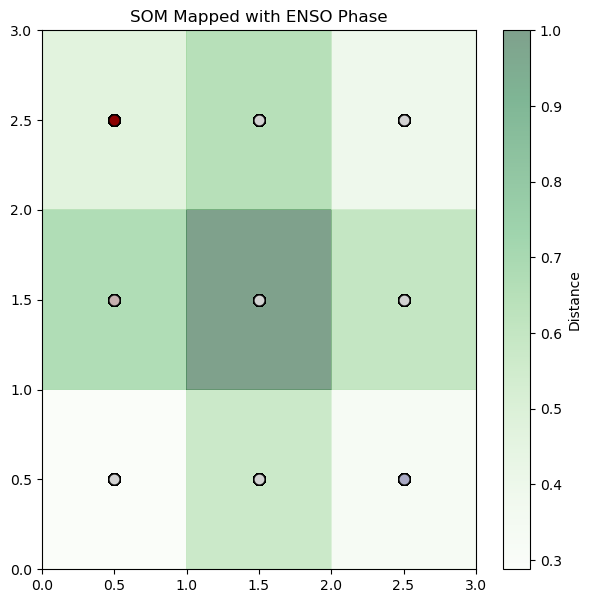

In [38]:
# Define a color map for ENSO phases
phase_colors = {
    'El Niño': 'darkred',
    'La Niña': 'darkblue',
    'Neutral': 'lightgray'
}

plt.figure(figsize=(7, 7))
plt.pcolor(som.distance_map().T, cmap='Greens', alpha=0.5)  # U-Matrix
plt.colorbar(label='Distance')

# Overlay points, color-coded by ENSO phase
for i, x in enumerate(latent_representations):
    winner = som.winner(x)
    label = enso_labels[i]
    plt.plot(winner[0] + 0.5, winner[1] + 0.5, 'o',
             markerfacecolor=phase_colors.get(label, 'black'),
             markeredgecolor='k', markersize=8, alpha=0.8)

plt.title('SOM Mapped with ENSO Phase')
plt.show()

In [39]:
enso_labels_full = oni_e3sm['enso_phase'].values

In [40]:
len(enso_labels_full) == latent_representations.shape[0]

True

In [41]:
latent_enso_phases = enso_labels_full  # 1-to-1 match per time step

In [42]:
latent_enso_phases

array(['Neutral', 'Neutral', 'Neutral', ..., 'La Niña', 'La Niña',
       'Neutral'], dtype='<U7')

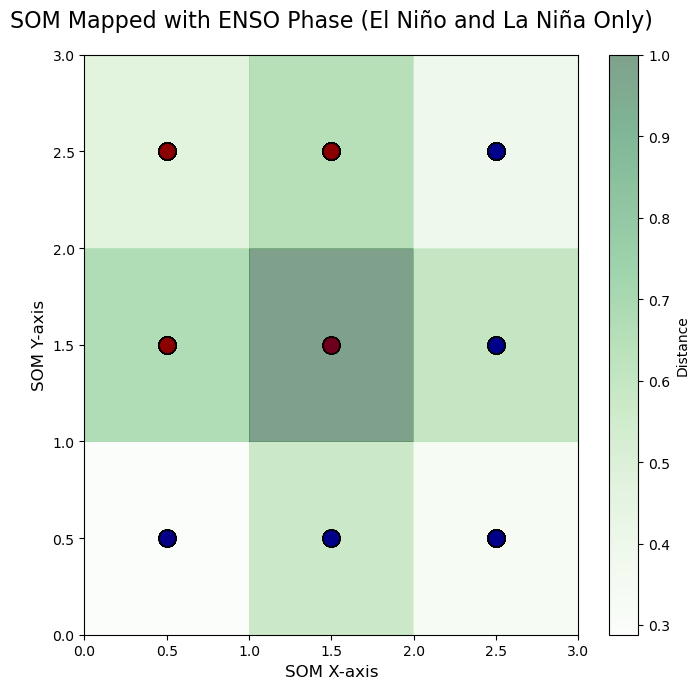

In [43]:
# filter out neutral cases to understand true enso distribution
filtered_data = [
    (x, label) for x, label in zip(latent_representations, enso_labels_full)
    if label != 'Neutral'
]

filtered_latents, filtered_labels = zip(*filtered_data)# Plot SOM
plt.figure(figsize=(7, 7))
plt.pcolor(som.distance_map().T, cmap='Greens', alpha=0.5)
plt.colorbar(label='Distance')

for x, label in zip(filtered_latents, filtered_labels):
    winner = som.winner(x)
    plt.plot(winner[0] + 0.5, winner[1] + 0.5, 'o',
             markerfacecolor=phase_colors[label],
             markeredgecolor='k', markersize=12, alpha=0.8)

plt.title('SOM Mapped with ENSO Phase (El Niño and La Niña Only)', fontsize=16, pad=20)
plt.xlabel('SOM X-axis', fontsize=12)
plt.ylabel('SOM Y-axis', fontsize=12)
plt.grid(False)  # Disable the grid for a cleaner look
plt.gca().set_facecolor('white')  # Set background color
plt.tight_layout()
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/scholarly_paper/3x3som_ninoninaonly.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [44]:
from collections import defaultdict

# create nested dictionary to count phases per node
node_counts = defaultdict(lambda: {'El Niño': 0, 'La Niña': 0})

# loop through filtered latent vectors and ENSO labels
for x, label in zip(filtered_latents, filtered_labels):
    winner = som.winner(x)
    node_counts[winner][label] += 1

In [45]:
print("SOM Node ENSO Phase Counts:")
for node, counts in sorted(node_counts.items()):
    print(f"Node {node}: El Niño = {counts['El Niño']}, La Niña = {counts['La Niña']}")

SOM Node ENSO Phase Counts:
Node (0, 0): El Niño = 28, La Niña = 2
Node (0, 1): El Niño = 266, La Niña = 0
Node (0, 2): El Niño = 384, La Niña = 0
Node (1, 0): El Niño = 0, La Niña = 30
Node (1, 1): El Niño = 9, La Niña = 9
Node (1, 2): El Niño = 141, La Niña = 2
Node (2, 0): El Niño = 0, La Niña = 572
Node (2, 1): El Niño = 0, La Niña = 75
Node (2, 2): El Niño = 3, La Niña = 129


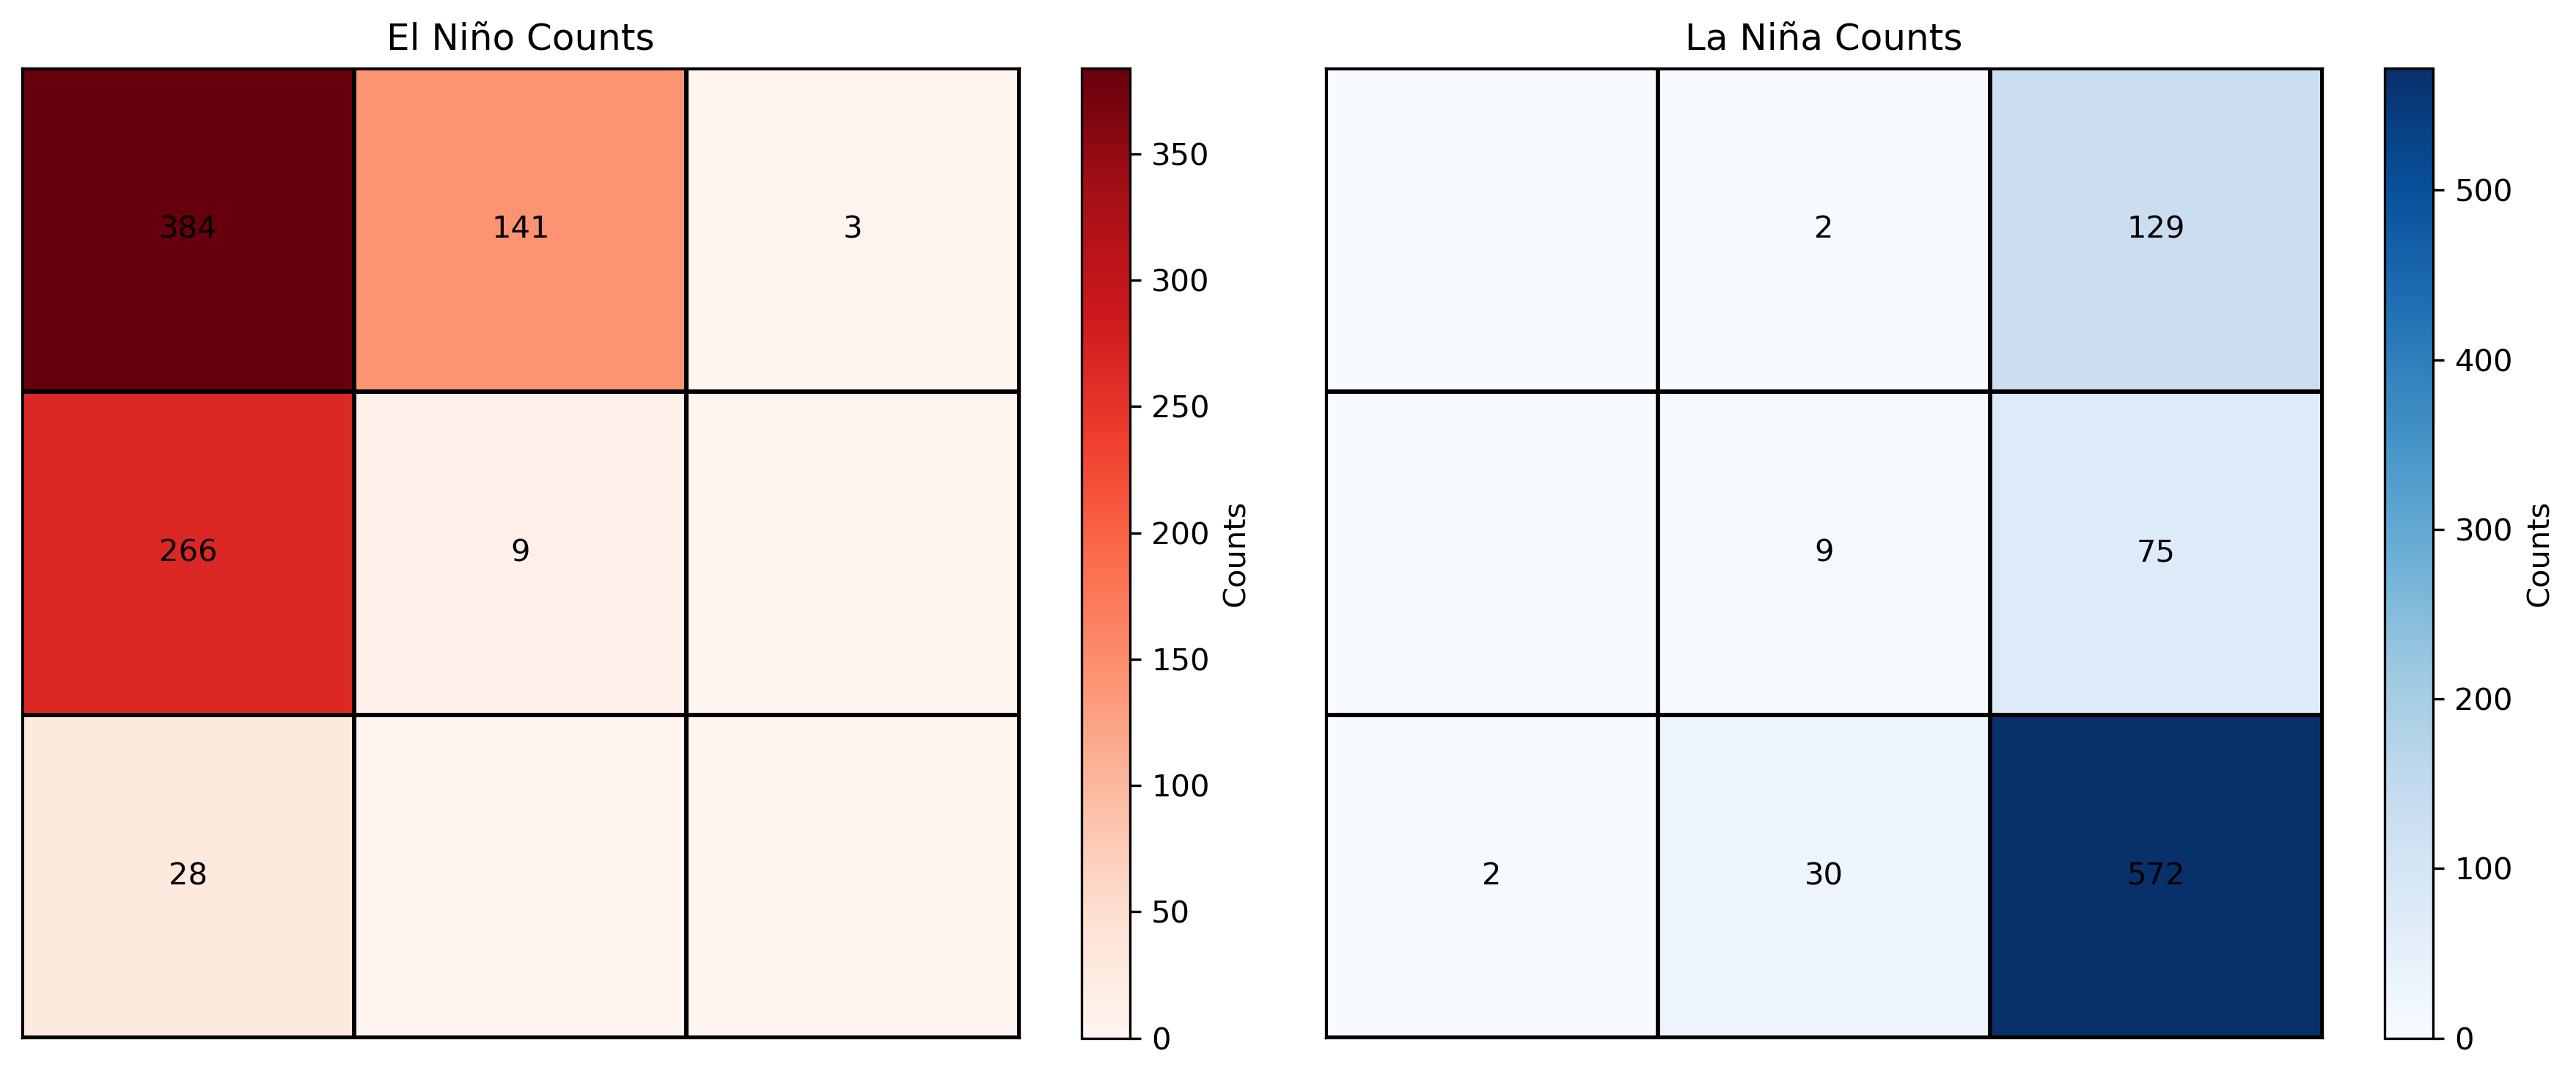

In [46]:
from matplotlib.backends.backend_pdf import PdfPages

# retrieve som grid size
n_rows, n_cols = som.get_weights().shape[:2]

# initialize count grids
el_nino_grid = np.zeros((n_rows, n_cols))
la_nina_grid = np.zeros((n_rows, n_cols))

# fill grids with counts
for (i, j), counts in node_counts.items():
    el_nino_grid[i, j] = counts.get('El Niño', 0)
    la_nina_grid[i, j] = counts.get('La Niña', 0)

# transpose for plotting
el_nino_grid = el_nino_grid.T
la_nina_grid = la_nina_grid.T

# grid edges
x = np.arange(n_cols + 1)
y = np.arange(n_rows + 1)
X, Y = np.meshgrid(x, y)

# plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# nino
pcm1 = axs[0].pcolormesh(X, Y, el_nino_grid, cmap='Reds', edgecolors='k', shading='auto')
axs[0].set_title("El Niño Counts")
for i in range(el_nino_grid.shape[0]):
    for j in range(el_nino_grid.shape[1]):
        count = int(el_nino_grid[i, j])
        if count > 0:
            axs[0].text(j + 0.5, i + 0.5, str(count), ha='center', va='center', color='black', fontsize=10)
cbar1 = fig.colorbar(pcm1, ax=axs[0])
cbar1.set_label('Counts')

# nina
pcm2 = axs[1].pcolormesh(X, Y, la_nina_grid, cmap='Blues', edgecolors='k', shading='auto')
axs[1].set_title("La Niña Counts")
for i in range(la_nina_grid.shape[0]):
    for j in range(la_nina_grid.shape[1]):
        count = int(la_nina_grid[i, j])
        if count > 0:
            axs[1].text(j + 0.5, i + 0.5, str(count), ha='center', va='center', color='black', fontsize=10)
cbar2 = fig.colorbar(pcm2, ax=axs[1])
cbar2.set_label('Counts')

# no ticks
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.show()

# Save PDF
#pdf_path = '/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/pr_paper/3x3som_0630_newseed.pdf'
#with PdfPages(pdf_path) as pdf:
#    pdf.savefig(fig, bbox_inches='tight', pad_inches=0.1)

#plt.close(fig)

In [47]:
# store BMU indices for each sample
bmu_indices = []
for x in filtered_latents:
    bmu_indices.append(som.winner(x))

In [48]:
bmu_indices[:10]

[(2, 1),
 (1, 2),
 (0, 2),
 (0, 2),
 (0, 1),
 (0, 1),
 (2, 0),
 (2, 0),
 (2, 0),
 (2, 0)]

# Field Reconstructions

In [54]:
filtered_latents

(array([-1.184498  , -0.05435753, -0.3653128 , -0.30700883,  0.07451137,
         1.063566  , -0.42757925, -0.02870138,  1.5661439 , -1.3977728 ,
        -0.9248566 ,  0.5101232 ,  0.8081472 ,  0.5431972 , -0.3457793 ,
         1.0063934 ,  0.9911443 , -2.5501728 , -0.64047515,  0.670725  ],
       dtype=float32),
 array([ 0.93561673,  0.06722286, -0.19644156, -0.40142545,  0.33238024,
        -0.5790806 ,  0.02239646,  0.66129756,  1.1074802 , -0.77374125,
        -1.4276403 ,  1.2653929 , -0.14969574,  0.39802954, -0.17351028,
        -0.17738482, -0.14093834, -1.1762431 , -0.4803157 , -1.2033266 ],
       dtype=float32),
 array([ 1.169033  , -0.23285791, -0.7843373 , -1.0386986 ,  0.8247274 ,
        -1.3057996 , -0.37942594,  0.6977421 , -0.21175602,  0.64248025,
        -1.6848139 ,  1.2428106 ,  0.37454945,  0.14672607, -0.10487989,
        -0.67028934, -0.3556137 , -0.6124279 , -0.52169514, -0.39449477],
       dtype=float32),
 array([ 1.5379380e+00, -5.1370406e-01, -3.3782321e-

In [55]:
filtered_labels

('La Niña',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'La Niña',
 'La Niña',
 'La Niña',
 'La Niña',
 'La Niña',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'La Niña',
 'La Niña',
 'La Niña',
 'La Niña',
 'El Niño',
 'La Niña',
 'La Niña',
 'La Niña',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El Niño',
 'El

In [49]:
node_counts

defaultdict(<function __main__.<lambda>()>,
            {(2, 1): {'El Niño': 0, 'La Niña': 75},
             (1, 2): {'El Niño': 141, 'La Niña': 2},
             (0, 2): {'El Niño': 384, 'La Niña': 0},
             (0, 1): {'El Niño': 266, 'La Niña': 0},
             (2, 0): {'El Niño': 0, 'La Niña': 572},
             (1, 0): {'El Niño': 0, 'La Niña': 30},
             (1, 1): {'El Niño': 9, 'La Niña': 9},
             (0, 0): {'El Niño': 28, 'La Niña': 2},
             (2, 2): {'El Niño': 3, 'La Niña': 129}})

In [88]:
# try SST field composites for each phase and node
# defaultdict allows you to initialize unseen keys using a function

from collections import defaultdict

# step 1: track original SST by node and phase
sst_by_node_phase = defaultdict(list)

for x_latent, sst_input, label in zip(filtered_latents, sst_sequential, filtered_labels):
    node = som.winner(x_latent)
    sst_by_node_phase[(node, label)].append(sst_input)

In [89]:
sst_by_node_phase[(0,2), 'El Niño']

[<xarray.DataArray (newdim: 2968)> Size: 12kB
 array([ 0.10382219,  0.08966852,  0.05962231, ..., -0.35251725,
        -0.27474537, -0.17154494], dtype=float32)
 Coordinates:
     time     object 8B 0001-03-01 00:00:00
     month    int64 8B 3
     lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
     lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
 Dimensions without coordinates: newdim,
 <xarray.DataArray (newdim: 2968)> Size: 12kB
 array([-0.40898532, -0.38697636, -0.39917377, ..., -0.5218962 ,
        -0.46276417, -0.42497894], dtype=float32)
 Coordinates:
     time     object 8B 0001-04-01 00:00:00
     month    int64 8B 4
     lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
     lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
 Dimensions without coordinates: newdim,
 <xarray.DataArray (newdim: 2968)> Size: 12kB
 array([ 0.20608494,  0.29341304,  0.29514182, ..., -0.493

In [90]:
# pull node (2, 0)
node_test = sst_by_node_phase[(0, 2), 'El Niño']

In [91]:
type(node_test)

list

In [92]:
# convert to xarray and preserve coordinates
node_test_xr = xr.concat(node_test, dim='time')

In [93]:
node_test_xr = node_test_xr * -1

In [94]:
node_test_xr

<xarray.DataArray (time: 384, newdim: 2968)> Size: 5MB
array([[-0.10382219, -0.08966852, -0.05962231, ...,  0.35251725,
         0.27474537,  0.17154494],
       [ 0.40898532,  0.38697636,  0.39917377, ...,  0.5218962 ,
         0.46276417,  0.42497894],
       [-0.20608494, -0.29341304, -0.29514182, ...,  0.49397048,
         0.56177664,  0.48369643],
       ...,
       [-0.7447633 , -0.8107118 , -0.84054065, ...,  0.33739555,
         0.33328846,  0.3303895 ],
       [-0.8215646 , -0.88216   , -1.0786635 , ...,  0.21798159,
         0.19825746,  0.32978544],
       [-0.27582207, -0.29382503, -0.3974627 , ...,  0.3678588 ,
         0.2616406 ,  0.16872431]], dtype=float32)
Coordinates:
  * time     (time) object 3kB 0001-03-01 00:00:00 ... 0138-03-01 00:00:00
    month    (time) int64 3kB 3 4 12 9 10 11 12 1 2 6 ... 6 3 4 5 10 11 12 1 2 3
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [95]:
# reconstruct grid function 
def reconstruct_grid(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (20)
        x_indx (numpy array): longitude indices for grid (150)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 20, 150), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d#.values
    
    # return predictions on original 2d grid
    return pred_grid

In [96]:
# load data from olr notebook
# indices can be loaded anytime and used for reconstruction
sst_yindx = np.load('sst_yindx.npy')
sst_xindx = np.load('sst_xindx.npy')

In [97]:
print(sst_yindx.shape, sst_xindx.shape)

(2968,) (2968,)


In [98]:
node_test_xr.shape

(384, 2968)

In [99]:
sst_vals = node_test_xr.values  # shape: (87, 2968)

In [100]:
sst_vals.shape

(384, 2968)

In [109]:
# import scaler to get physical sst values
scaler_sst = joblib.load('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/scaler_sst.pkl')

print(type(scaler_sst))

<class 'sklearn.preprocessing._data.RobustScaler'>


In [110]:
sst_physical_vals = scaler_sst.inverse_transform(sst_vals)  # shape: (87, 2968)

In [111]:
sst_physical_vals

array([[-0.09034524, -0.0779625 , -0.06205601, ...,  0.1739056 ,
         0.13311361,  0.07404158],
       [ 0.24153969,  0.23270243,  0.23574606, ...,  0.2649734 ,
         0.23572347,  0.210148  ],
       [-0.15652888, -0.21075797, -0.21493044, ...,  0.24995896,
         0.28975877,  0.24168217],
       ...,
       [-0.50515723, -0.54792005, -0.5689459 , ...,  0.1657753 ,
         0.16506305,  0.15934886],
       [-0.5548624 , -0.59448814, -0.7235101 , ...,  0.10157152,
         0.0913709 ,  0.15902445],
       [-0.2016622 , -0.21102649, -0.28134638, ...,  0.18215409,
         0.12596178,  0.07252676]], dtype=float32)

In [103]:
sst_physical_composite = sst_physical_vals.mean(axis=0)  # shape: (2968,)

In [104]:
sst_physical_composite.shape

(2968,)

In [105]:
# reconstruct grid now with NaNs
node20_sst_grid = reconstruct_grid(sst_physical_composite[None, :], sst_yindx, sst_xindx)

In [106]:
node20_sst_grid.shape

(1, 20, 150)

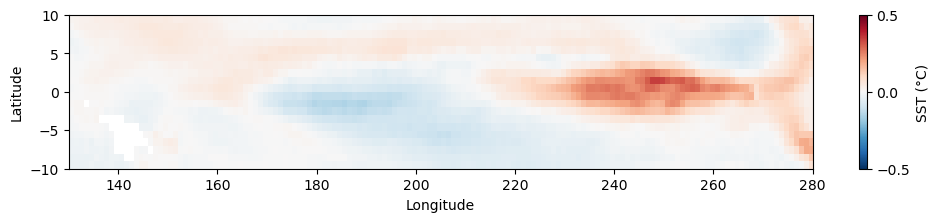

In [107]:
# Define latitude and longitude ranges
lat_bounds = (-10, 10)
lon_bounds = (130, 280)

# Handle NaNs by computing min/max without NaNs
vmin = -0.5
vmax = 0.5

node20_sst_grid_2d = np.squeeze(node20_sst_grid)  # shape becomes (20, 150)

# Create the figure
plt.figure(figsize=(12, 2))

# Plot the data with the RdBu_r colormap and set extent for lat/lon labels
cax = plt.imshow(node20_sst_grid_2d, aspect='auto', cmap='RdBu_r', origin='lower', 
                 extent=[lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]], vmin=vmin, vmax=vmax)

# Add a colorbar with center at 0
cbar = plt.colorbar(cax, label='SST (\u00b0C)', orientation='vertical')
cbar.set_ticks([vmin, 0, vmax])  # Ensure 0 is explicitly labeled

# Add labels
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.title(r'SST: $\mu_1 = 5$')

plt.show()

## 2D KDE

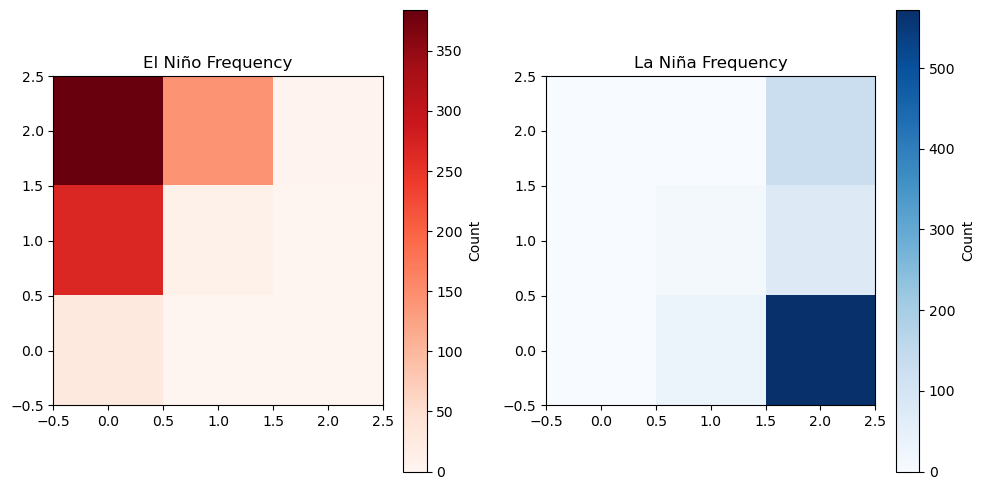

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Initialize count dictionary
node_phase_counts = defaultdict(lambda: {'El Niño': 0, 'La Niña': 0})

# Loop through latent vectors and their labels
for latent_vec, label in zip(filtered_latents, filtered_labels):
    bmu = som.winner(latent_vec)  # Best matching unit (x, y)
    if label in ['El Niño', 'La Niña']:  # Optional safety check
        node_phase_counts[bmu][label] += 1

# Create empty 2D arrays for heatmaps
el_nino_counts = np.zeros((som_size, som_size))
la_nina_counts = np.zeros((som_size, som_size))

for (x, y), counts in node_phase_counts.items():
    el_nino_counts[x, y] = counts['El Niño']
    la_nina_counts[x, y] = counts['La Niña']


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

im1 = axes[0].imshow(el_nino_counts.T, origin='lower', cmap='Reds')
axes[0].set_title('El Niño Frequency')
fig.colorbar(im1, ax=axes[0], label='Count')

im2 = axes[1].imshow(la_nina_counts.T, origin='lower', cmap='Blues')
axes[1].set_title('La Niña Frequency')
fig.colorbar(im2, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

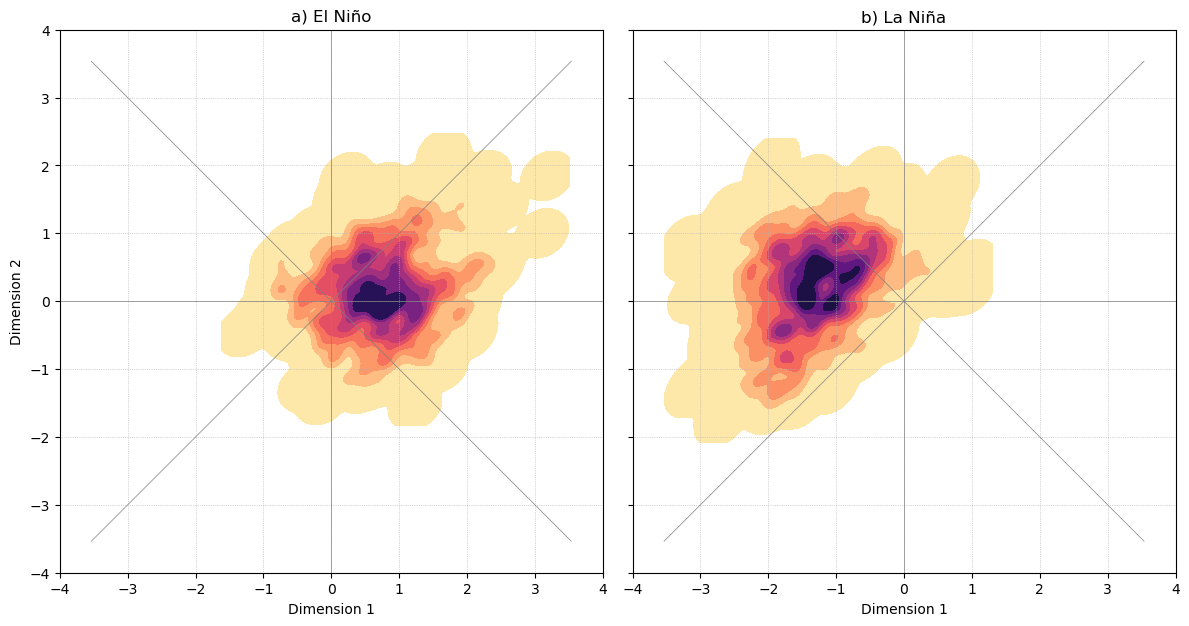

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to NumPy arrays for indexing
filtered_latents = np.array(filtered_latents)
filtered_labels = np.array(filtered_labels)

# Boolean masks
mask_nino = filtered_labels == 'El Niño'
mask_nina = filtered_labels == 'La Niña'

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# KDE plot settings
kde_kwargs = dict(fill=True, cmap='magma_r', bw_adjust=0.5, thresh=1e-5)

titles = ["a) El Niño", "b) La Niña"]
datasets = [
    (filtered_latents[mask_nino, 0], filtered_latents[mask_nino, 1]),
    (filtered_latents[mask_nina, 0], filtered_latents[mask_nina, 1]),
]

for ax, (x, y), title in zip(axes, datasets, titles):
    sns.kdeplot(x=x, y=y, ax=ax, **kde_kwargs)
    ax.set_title(title)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    
    # Add radial lines from center
    for angle in np.linspace(0, 2*np.pi, 8, endpoint=False):
        dx = np.cos(angle) * 5
        dy = np.sin(angle) * 5
        ax.plot([0, dx], [0, dy], color='gray', linestyle='-', linewidth=0.5)

    # Add dotted gridlines
    ax.set_xticks(np.arange(-4, 5, 1))
    ax.set_yticks(np.arange(-4, 5, 1))
    ax.grid(True, linestyle=':', linewidth=0.5)

plt.tight_layout()
plt.show()

## Markov Chain

In [ ]:
# useful for dynamics
# how ENSO events evolve over time through the latent-SOM space
# tracks the sequence of SOM nodes over time 
# looks at which nodes are stable vs transitional 

In [111]:
som_nodes = []
for latent in latent_representations:
    bmu = som.winner(latent)
    som_nodes.append(bmu)

In [112]:
som_size = som._weights.shape[0]  # assuming square SOM
node_to_index = lambda x, y: x * som_size + y

# Flatten BMUs to indices
node_indices = [node_to_index(x, y) for (x, y) in som_nodes]

n_nodes = som_size * som_size
transition_counts = np.zeros((n_nodes, n_nodes), dtype=int)

# Count transitions
for i in range(len(node_indices) - 1):
    from_node = node_indices[i]
    to_node = node_indices[i + 1]
    transition_counts[from_node, to_node] += 1

In [113]:
transition_matrix = transition_counts.astype(float)
row_sums = transition_matrix.sum(axis=1, keepdims=True)
transition_matrix = np.divide(
    transition_matrix, row_sums, 
    out=np.zeros_like(transition_matrix), where=row_sums != 0
)

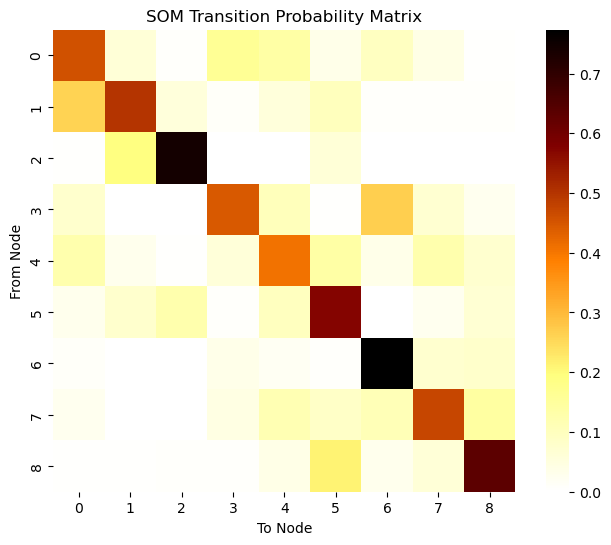

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(transition_matrix, cmap='afmhot_r', square=True)
plt.title("SOM Transition Probability Matrix")
plt.xlabel("To Node")
plt.ylabel("From Node")
plt.show()

In [116]:
som_coords = []  # list of (x, y)
for vec in latent_representations:
    bmu = som.winner(vec)
    som_coords.append(bmu)

som_coords = np.array(som_coords)


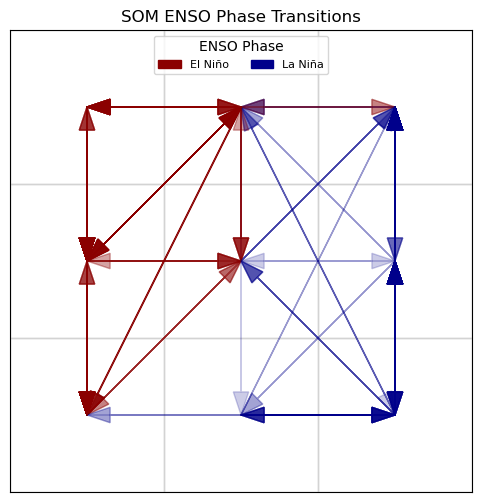

In [144]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Optional: Map phase to color
phase_colors = {
    'El Niño': 'darkred',
    'La Niña': 'darkblue',
#    'Neutral': 'lightgray'
}

plt.figure(figsize=(6, 6))
plt.title("SOM ENSO Phase Transitions")

# Plot grid
for i in range(som_size):
    for j in range(som_size):
        plt.gca().add_patch(plt.Rectangle((i - 0.5, j - 0.5), 1, 1,
                                          edgecolor='lightgray', facecolor='none'))

# Plot transitions as arrows
for t in range(len(som_coords) - 1):
    x0, y0 = som_coords[t]
    x1, y1 = som_coords[t + 1]
    phase = enso_labels_full[t]

    if phase == 'Neutral':
        continue # skip neutral phases for fun?

    plt.arrow(x0, y0, x1 - x0, y1 - y0,
              color=phase_colors.get(phase, 'black'),
              alpha=0.2, head_width=0.1, length_includes_head=True, 
             zorder=3)

plt.xlim(-0.5, som_size - 0.5)
plt.ylim(-0.5, som_size - 0.5)
plt.gca().set_aspect('equal')
#plt.xticks(range(som_size))
#plt.yticks(range(som_size))
plt.xticks([])
plt.yticks([])

# Legend
handles = [mpatches.Patch(color=color, label=label) for label, color in phase_colors.items()]
plt.legend(handles=handles, title="ENSO Phase", ncols=3, loc='upper center', fontsize=8)

plt.grid(False)
plt.show()